Index(['Draw Date', 'Winning Numbers', 'Mega Ball', 'Multiplier'], dtype='object')


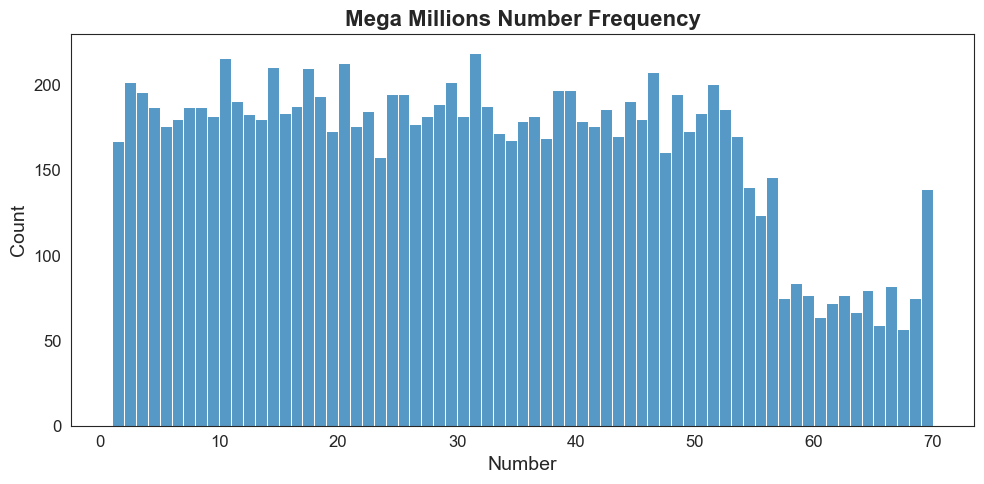

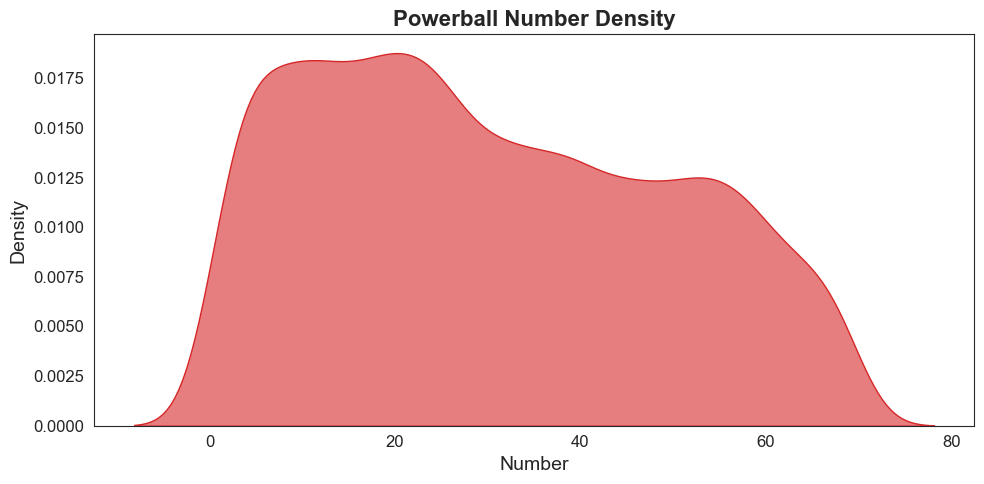

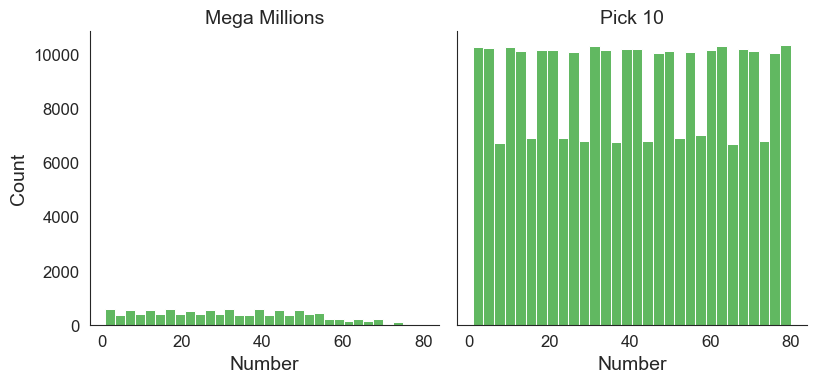

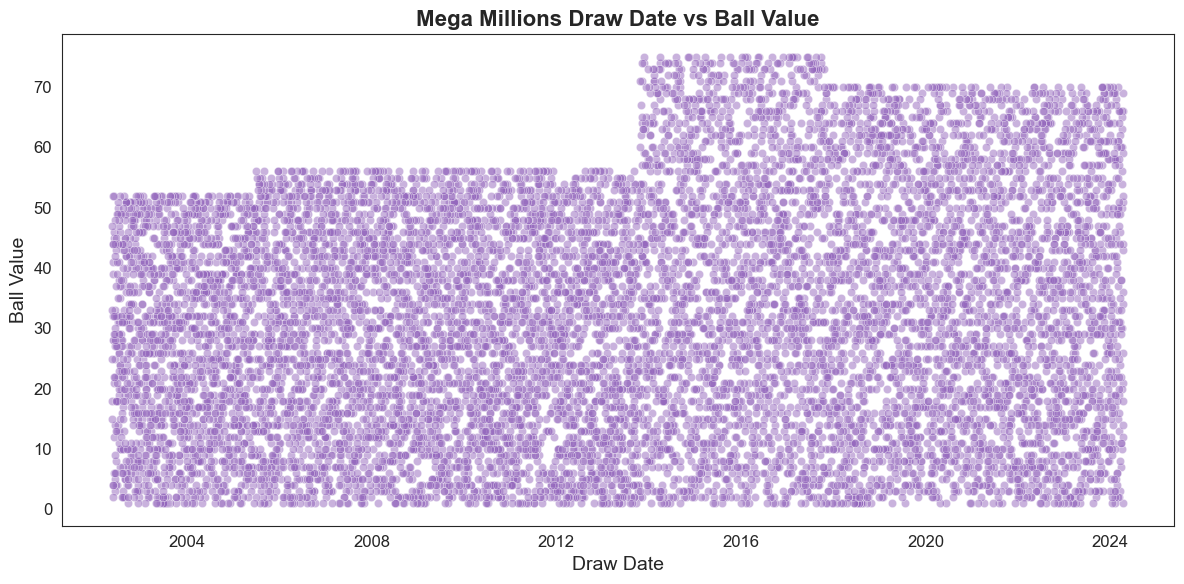

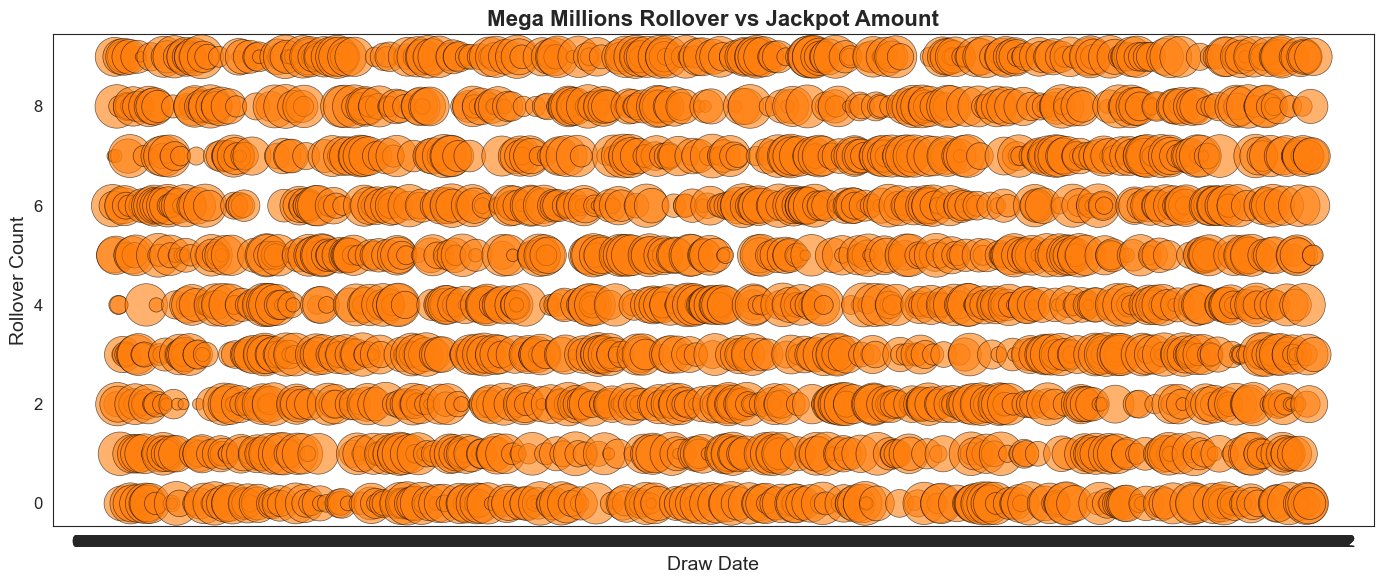

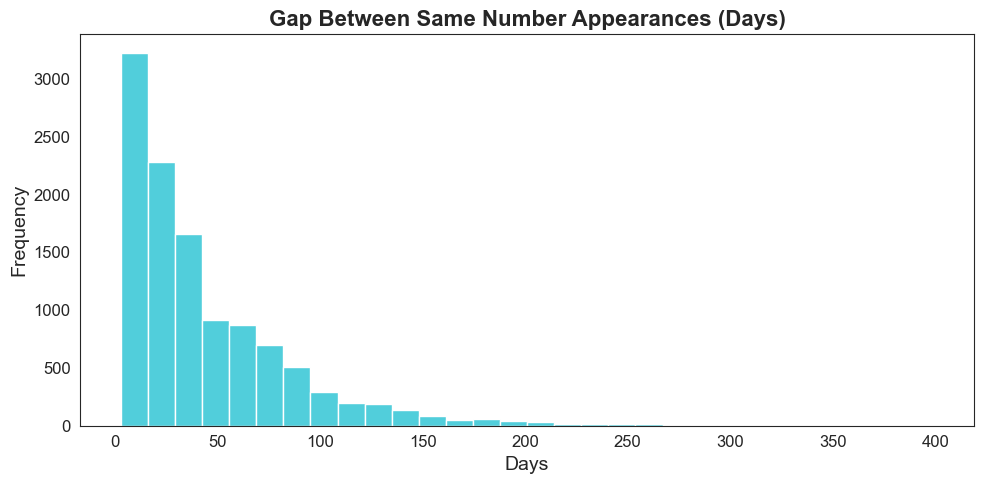

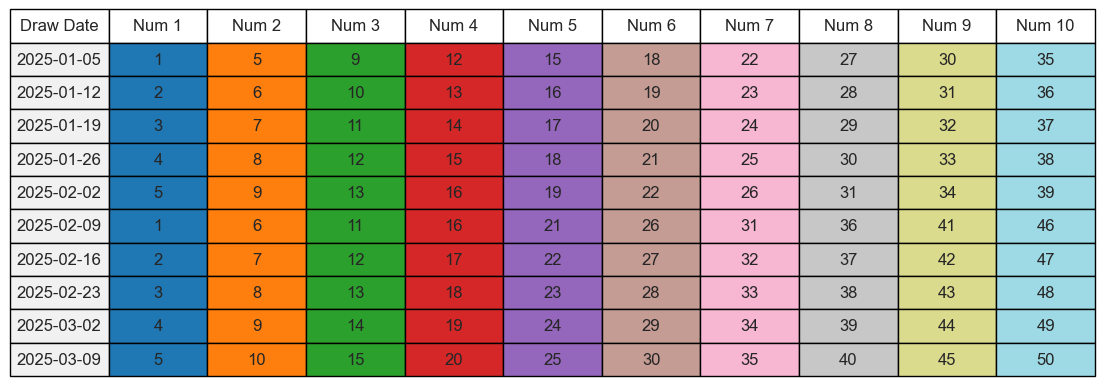

In [1]:
# Lottery Analysis Project
# Assignment 7 & 8, Megan Pokal, DSC 640

# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Style for infographic
sns.set_style("white")
plt.rcParams.update({'font.size': 12, 'axes.titlesize':16, 'axes.labelsize':14})

# Load all three datasets
# Changed dataset names for easier read
mega = pd.read_csv("/Users/meganpokal/PyCharmMiscProject/mega_millions.csv")
pick10 = pd.read_csv("/Users/meganpokal/PyCharmMiscProject/pick10.csv")
powerball = pd.read_csv("/Users/meganpokal/PyCharmMiscProject/powerball.csv")

# Print columns
print(mega.columns)

# Data fix for Mega Millions
mega[['N1','N2','N3','N4','N5']] = mega['Winning Numbers'].str.split(' ', expand=True).astype(int)
mega_exp = mega.melt(id_vars=['Draw Date'],
                     value_vars=['N1','N2','N3','N4','N5'],
                     var_name='Ball Position', value_name='Ball Value')
mega_exp['Ball Value'] = mega_exp['Ball Value'].astype(int)
mega_exp['Draw Date'] = pd.to_datetime(mega_exp['Draw Date'])
mega_exp['Game'] = 'Mega Millions'

# Data fix for Powerball
# Convert 'Winning Numbers' into a list of integers
powerball['Winning Numbers List'] = powerball['Winning Numbers'].str.strip().str.split(r'\s+').apply(lambda x: [int(n) for n in x])

# Optionally, explode the list into separate rows for each ball
power_exp = powerball[['Draw Date', 'Winning Numbers List', 'Multiplier']].explode('Winning Numbers List')

# Rename for clarity
power_exp = power_exp.rename(columns={'Winning Numbers List': 'Ball Value'})

# Convert types
power_exp['Ball Value'] = power_exp['Ball Value'].astype(int)
power_exp['Draw Date'] = pd.to_datetime(power_exp['Draw Date'])

# Data fix for Pick 10
pick10_numbers = pick10['Winning Numbers'].str.split(' ', expand=True).astype(int)
pick10_cols = [f'N{i+1}' for i in range(pick10_numbers.shape[1])]
pick10_numbers.columns = pick10_cols
pick10 = pd.concat([pick10['Draw Date'], pick10_numbers], axis=1)
pick10_exp = pick10.melt(id_vars=['Draw Date'],
                         value_vars=pick10_cols,
                         var_name='Ball Position', value_name='Ball Value')
pick10_exp['Ball Value'] = pick10_exp['Ball Value'].astype(int)
pick10_exp['Draw Date'] = pd.to_datetime(pick10_exp['Draw Date'])
pick10_exp['Game'] = 'Pick 10'

# Combine all games for small multiples
all_games = pd.concat([mega_exp, power_exp, pick10_exp], ignore_index=True)

# Graph 1: Histogram - Mega Millions Frequency
plt.figure(figsize=(10,5))
sns.histplot(mega_exp['Ball Value'], bins=range(1,71), kde=False, color='#1f77b4')
plt.title("Mega Millions Number Frequency", fontsize=16, fontweight='bold')
plt.xlabel("Number")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Graph 2: Density Plot - Powerball
plt.figure(figsize=(10,5))
sns.kdeplot(power_exp['Ball Value'], fill=True, color='#d62728', alpha=0.6)
plt.title("Powerball Number Density", fontsize=16, fontweight='bold')
plt.xlabel("Number")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Graph 3: Small Multiples - Frequency per Game
g = sns.FacetGrid(all_games, col='Game', col_wrap=3, height=4, sharey=True)
g.map_dataframe(sns.histplot, x='Ball Value', bins=30, color='#2ca02c')
g.set_titles("{col_name}", fontsize=14)
g.set_axis_labels("Number", "Count")
plt.tight_layout()
plt.show()

# Graph 4: Scatterplot - Draw Date vs Ball Value (Mega Millions)
plt.figure(figsize=(12,6))
sns.scatterplot(data=mega_exp, x='Draw Date', y='Ball Value', alpha=0.5, color='#9467bd')
plt.title("Mega Millions Draw Date vs Ball Value", fontsize=16, fontweight='bold')
plt.xlabel("Draw Date")
plt.ylabel("Ball Value")
plt.tight_layout()
plt.show()

# Graph 5: Bubble Chart - Rollover vs Jackpot Amount
# Simulate Rollover Count & Jackpot Amount
mega_rollover = mega.copy()
mega_rollover['Rollover Count'] = np.random.randint(0, 10, size=len(mega_rollover))
mega_rollover['Jackpot Amount'] = np.random.randint(10_000_000, 200_000_000, size=len(mega_rollover))

# Normalize bubble sizes for better visibility
bubble_size = mega_rollover['Jackpot Amount'] / mega_rollover['Jackpot Amount'].max() * 1000

plt.figure(figsize=(14,6))
scatter = plt.scatter(mega_rollover['Draw Date'], mega_rollover['Rollover Count'],
                      s=bubble_size, alpha=0.6, color='#ff7f0e', edgecolors='k', linewidth=0.5)

plt.title("Mega Millions Rollover vs Jackpot Amount", fontsize=16, fontweight='bold')
plt.xlabel("Draw Date")
plt.ylabel("Rollover Count")
plt.tight_layout()
plt.show()

# Graph 6: Histogram - Gap between same number appearances (Mega Millions)
mega_exp_sorted = mega_exp.sort_values(['Ball Value','Draw Date'])
mega_exp_sorted['Prev Draw'] = mega_exp_sorted.groupby('Ball Value')['Draw Date'].shift(1)
mega_exp_sorted['Gap'] = (mega_exp_sorted['Draw Date'] - mega_exp_sorted['Prev Draw']).dt.days

plt.figure(figsize=(10,5))
sns.histplot(mega_exp_sorted['Gap'].dropna(), bins=30, color='#17becf')
plt.title("Gap Between Same Number Appearances (Days)", fontsize=16, fontweight='bold')
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Graph 7: Pick 10 Table
pick10 = pd.DataFrame({
    "Draw Date": pd.date_range(start="2025-01-01", periods=10, freq='W'),
    "Winning Numbers": [
        "1 5 9 12 15 18 22 27 30 35",
        "2 6 10 13 16 19 23 28 31 36",
        "3 7 11 14 17 20 24 29 32 37",
        "4 8 12 15 18 21 25 30 33 38",
        "5 9 13 16 19 22 26 31 34 39",
        "1 6 11 16 21 26 31 36 41 46",
        "2 7 12 17 22 27 32 37 42 47",
        "3 8 13 18 23 28 33 38 43 48",
        "4 9 14 19 24 29 34 39 44 49",
        "5 10 15 20 25 30 35 40 45 50"
    ]
})

# Format Draw Date to only show date
pick10['Draw Date'] = pick10['Draw Date'].dt.strftime('%Y-%m-%d')

# Split Winning Numbers into separate columns
numbers_split = pick10['Winning Numbers'].str.split(' ', expand=True).astype(int)
numbers_split.columns = [f'Num {i+1}' for i in range(numbers_split.shape[1])]
table_data = pd.concat([pick10['Draw Date'], numbers_split], axis=1)

# Create color map for numbers (10 distinct colors)
colors = plt.cm.tab20(np.linspace(0, 1, 10))
cell_colors = [['#f1f1f1'] + [colors[j % 10] for j in range(numbers_split.shape[1])]
               for i in range(len(table_data))]

# Plot the table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellColours=cell_colors,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 2)

plt.show()
